# **Market Baket Analysis Project**


**Marco** **Catoia** **67031A**

# **1. Data Acquisition and Preparation**

Importing the dataset using Kaggle API

In [2]:
!pip install kaggle -q

In [3]:
import os
import zipfile

os.environ['KAGGLE_USERNAME'] = "xxxxxx"
os.environ['KAGGLE_KEY'] = "xxxxxx"
!kaggle datasets download -d harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows

with zipfile.ZipFile('imdb-dataset-of-top-1000-movies-and-tv-shows.zip', 'r') as zip_file:
    zip_file.extractall('.')

Dataset URL: https://www.kaggle.com/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows
License(s): CC0-1.0
100% 175k/175k [00:00<00:00, 103MB/s]



Importing the necessary libraries

In [4]:
import pandas as pd
from itertools import combinations
import time
import matplotlib.pyplot as plt

Reading the csv and checking properties of the data

In [5]:
df = pd.read_csv('imdb_top_1000.csv')
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("Column list:")
print(df.columns.tolist())
print("First 5 rows:")
df.head()

Rows: 1000, Columns: 16
Column list:
['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate', 'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director', 'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross']
First 5 rows:


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


# **2. Data Organization and Preprocessing**

Selecting the columns we need

In [6]:
actor_columns = ['Star1', 'Star2', 'Star3', 'Star4']
print("Missing values for each column:")
print(df[actor_columns].isnull().sum())

Missing values for each column:
Star1    0
Star2    0
Star3    0
Star4    0
dtype: int64


Collecting unique actors

In [7]:
all_actors = set()
for col in actor_columns:
    all_actors.update(df[col].dropna())


Mapping actors to IDs and viceversa

In [8]:
actor_to_id = {actor: idx for idx, actor in enumerate(sorted(all_actors))}

id_to_actor = {idx: actor for actor, idx in actor_to_id.items()}

print(f"Number of unique actors: {len(actor_to_id)}")

Number of unique actors: 2709


Building **Baskets**

In [9]:
baskets = []
for _, row in df[actor_columns].iterrows():
    basket = set(actor_to_id[actor] for actor in row)
    baskets.append(basket)

print(f"Total number of baskets: {len(baskets)}")

print(f"\nFirst 3 baskets (with integers IDs):")
for i, basket in enumerate(baskets[:3]):
    print(f"Film {i+1}: {basket}")

print(f"\nFirst 3 baskets (with actor names):")
for i, basket in enumerate(baskets[:3]):
    print(f"Film {i+1}: {set(id_to_actor[idx] for idx in basket)}")


Total number of baskets: 1000

First 3 baskets (with integers IDs):
Film 1: {2640, 2482, 278, 1831}
Film 2: {578, 35, 1053, 1663}
Film 3: {930, 2, 1748, 438}

First 3 baskets (with actor names):
Film 1: {'William Sadler', 'Morgan Freeman', 'Bob Gunton', 'Tim Robbins'}
Film 2: {'Al Pacino', 'James Caan', 'Diane Keaton', 'Marlon Brando'}
Film 3: {'Heath Ledger', 'Aaron Eckhart', 'Michael Caine', 'Christian Bale'}


Fixing **support treshold** at 0,3%

In [10]:
N = len(baskets)
support_threshold = 0.003
abs_support_threshold = round(support_threshold * N)

# **3. A Priori Algorithm**

In [11]:
# PASS 1 A-PRIORI: we count the single actors and we filter the frequent ones

def apriori_pass1(baskets, absolute_support_threshold):

    count = {}
    for basket in baskets:
        for item in basket:
            if item in count:
                count[item] += 1
            else:
                count[item] = 1

    L1 = {}
    for item, cnt in count.items():
        if cnt >= absolute_support_threshold:
            L1[item] = cnt

    return L1


# PASS 2 A-PRIORI: we filter frequent items, generate all couples and we count them.
# then we filter only frequent couples

def apriori_pass2(baskets, L1, absolute_support_threshold):

    count = {}
    for basket in baskets:
        frequent_in_basket = [item for item in basket if item in L1]
        for pair in combinations(sorted(frequent_in_basket), 2):
            if pair in count:
                count[pair] += 1
            else:
                count[pair] = 1

    L2 = {}
    for pair, cnt in count.items():
        if cnt >= absolute_support_threshold:
            L2[pair] = cnt

    return L2


# Complete A-Prioiri Algorithm

def apriori(baskets, absolute_support_threshold):
    L1 = apriori_pass1(baskets, absolute_support_threshold)
    L2 = apriori_pass2(baskets, L1, absolute_support_threshold)
    return {1: L1, 2: L2}


In [12]:
frequent_itemsets_apriori = apriori(baskets, abs_support_threshold)
print(f"Frequent actors: {len(frequent_itemsets_apriori[1])}")
print(f"Frequent couples of actors: {len(frequent_itemsets_apriori[2])}")

Frequent actors: 271
Frequent couples of actors: 25


(Tried also to implement a third pass of a priori to find freq triples, but it has not been considered in the final report)

In [13]:
# Attempt to extend A-Priori to find frequent triples

def apriori_pass3(baskets, L1, L2, absolute_support_threshold):
    count = {}
    for basket in baskets:
        frequent_in_basket = [item for item in basket if item in L1]
        for triple in combinations(sorted(frequent_in_basket), 3):
            is_valid = True
            for pair in combinations(triple, 2):
                if pair not in L2:
                    is_valid = False
                    break
            if is_valid:
                if triple in count:
                    count[triple] += 1
                else:
                    count[triple] = 1
    L3 = {}
    for triple, cnt in count.items():
        if cnt >= absolute_support_threshold:
            L3[triple] = cnt
    return L3

L3 = apriori_pass3(baskets, frequent_itemsets_apriori[1], frequent_itemsets_apriori[2], abs_support_threshold)
print(f"Frequent triples of actors: {len(L3)}")

Frequent triples of actors: 3


In [14]:
def apriori_with_third_pass(baskets, absolute_support_threshold):
    results = apriori(baskets, absolute_support_threshold)
    L3 = apriori_pass3(baskets, results[1], results[2], absolute_support_threshold)
    results[3] = L3
    return results

In [15]:
frequent_itemsets_apriori_with_third_pass = apriori_with_third_pass(baskets, abs_support_threshold)
print(f"Frequent actors: {len(frequent_itemsets_apriori_with_third_pass[1])}")
print(f"Frequent couples: {len(frequent_itemsets_apriori_with_third_pass[2])}")
print(f"Frequent triples: {len(frequent_itemsets_apriori_with_third_pass[3])}")

Frequent actors: 271
Frequent couples: 25
Frequent triples: 3


# **4. PCY Algorithm**

In [16]:
# PASS 1 PCY: Counts singletons, and gives frequent ones.
#In addition generates possible pairsof a basket, hashes them and adds 1 to their count in the hash table

def pcy_pass1(baskets, absolute_support_threshold, num_buckets):

    singleton_count = {}
    hash_table = [0] * num_buckets

    for basket in baskets:
        for item in basket:
            if item in singleton_count:
                singleton_count[item] += 1
            else:
                singleton_count[item] = 1

        for pair in combinations(sorted(basket), 2):
            bucket = hash(pair) % num_buckets
            hash_table[bucket] += 1

    L1 = {}
    for item, cnt in singleton_count.items():
        if cnt >= absolute_support_threshold:
            L1[item] = cnt

    return L1, hash_table


#Bitmap Construction

def build_bitmap(hash_table, absolute_support_threshold):
    bitmap = []
    for count in hash_table:
        if count >= absolute_support_threshold:
            bitmap.append(1)
        else:
            bitmap.append(0)
    return bitmap


# PASS 2 PCY: Finds candidate pair using L1, and counts only pairs hashed in a frequent bucket (bitmap value 1)

def pcy_pass2(baskets, L1, bitmap, num_buckets, absolute_support_threshold):

    count = {}
    for basket in baskets:
        frequent_in_basket = [item for item in basket if item in L1]
        for pair in combinations(sorted(frequent_in_basket), 2):
            bucket = hash(pair) % num_buckets
            if bitmap[bucket] == 1:
                if pair in count:
                    count[pair] += 1
                else:
                    count[pair] = 1

    L2 = {}
    for pair, cnt in count.items():
        if cnt >= absolute_support_threshold:
            L2[pair] = cnt

    return L2


# Complete PCY algorithm

def pcy(baskets, absolute_support_threshold, num_buckets=10000):
    L1, hash_table = pcy_pass1(baskets, absolute_support_threshold, num_buckets)
    bitmap = build_bitmap(hash_table, absolute_support_threshold)
    L2 = pcy_pass2(baskets, L1, bitmap, num_buckets, absolute_support_threshold)
    return {1: L1, 2: L2}

In [17]:
frequent_itemsets_pcy = pcy(baskets, abs_support_threshold)
print(f"Frequent actors: {len(frequent_itemsets_pcy[1])}")
print(f"Frequent couples of actors: {len(frequent_itemsets_pcy[2])}")

Frequent actors: 271
Frequent couples of actors: 25


# **5. Comparison and Scalability**

Verify the two algorithms provide **same results**

In [18]:
if frequent_itemsets_apriori == frequent_itemsets_pcy:
    print("A priori and PCY provided the same results")
else:
    print("Error in the definition of the algorithms")

A priori and PCY provided the same results


Showing most frequent Couples

In [22]:
print("The frequent couples are:")
for itemset, count in frequent_itemsets_apriori[2].items():
    names = sorted(id_to_actor[idx] for idx in itemset)
    print(f"{names}, support: {count}")

The frequent couples are:
['Al Pacino', 'Diane Keaton'], support: 3
['Christian Bale', 'Michael Caine'], support: 3
['Al Pacino', 'Robert De Niro'], support: 3
['Elijah Wood', 'Ian McKellen'], support: 3
['Elijah Wood', 'Orlando Bloom'], support: 3
['Ian McKellen', 'Orlando Bloom'], support: 3
['Joe Pesci', 'Robert De Niro'], support: 4
['Carrie Fisher', 'Harrison Ford'], support: 3
['Carrie Fisher', 'Mark Hamill'], support: 3
['Harrison Ford', 'Mark Hamill'], support: 3
['Takashi Shimura', 'Toshirô Mifune'], support: 3
['Chris Evans', 'Joe Russo'], support: 3
['Chris Evans', 'Robert Downey Jr.'], support: 3
['Joe Russo', 'Robert Downey Jr.'], support: 3
['Mark Ruffalo', 'Robert Downey Jr.'], support: 3
['Tatsuya Nakadai', 'Toshirô Mifune'], support: 3
['Tim Allen', 'Tom Hanks'], support: 4
['Daniel Radcliffe', 'Emma Watson'], support: 5
['Daniel Radcliffe', 'Rupert Grint'], support: 6
['Emma Watson', 'Rupert Grint'], support: 5
['Ethan Hawke', 'Julie Delpy'], support: 3
['Chris Evans'

Verifying **scalability** showing the avg computational time of the two algorithms (since we have a small dataset that allow us to do this quickly)

In [44]:
#Setting fractions to split the dataset
fractions = [0.2, 0.4, 0.6, 0.8, 1.0]
apriori_times = []
pcy_times = []
repetitions = 25

for fraction in fractions:
    subset_size = round(fraction * N)
    basket_subset = baskets[:subset_size]
    subset_apriori_runs = []
    subset_pcy_runs = []

    #Measuring computational time for A-Priori
    for repetition in range(repetitions):
      start = time.time()
      apriori(basket_subset, abs_support_threshold)
      subset_apriori_runs.append(time.time() - start)

    #Measuring computational time for A-Priori
      start = time.time()
      pcy(basket_subset, abs_support_threshold)
      subset_pcy_runs.append(time.time() - start)

    apriori_times.append(sum(subset_apriori_runs) / repetitions)
    pcy_times.append(sum(subset_pcy_runs) / repetitions)

    print(f"Subset {fraction:.0%} (Mean on {repetitions} run): "f"A-Priori = {apriori_times[-1]:.4f}s, PCY = {pcy_times[-1]:.4f}s")

Subset 20% (Mean on 25 run): A-Priori = 0.0002s, PCY = 0.0007s
Subset 40% (Mean on 25 run): A-Priori = 0.0004s, PCY = 0.0011s
Subset 60% (Mean on 25 run): A-Priori = 0.0006s, PCY = 0.0016s
Subset 80% (Mean on 25 run): A-Priori = 0.0009s, PCY = 0.0021s
Subset 100% (Mean on 25 run): A-Priori = 0.0011s, PCY = 0.0027s


Plotting the result

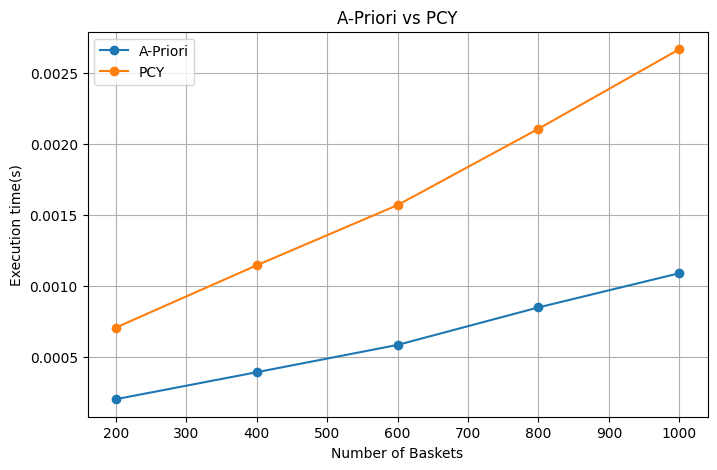

In [45]:
plt.figure(figsize=(8, 5))

plt.plot([f * N for f in fractions], apriori_times, marker='o', label='A-Priori')
plt.plot([f * N for f in fractions], pcy_times, marker='o', label='PCY')

plt.xlabel("Number of Baskets")
plt.ylabel("Execution time(s)")
plt.title("A-Priori vs PCY")
plt.legend()
plt.grid(True)

plt.show()